(debugging)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# اشکال‌زدایی و مدیریت خطاها

```{index} single: Debugging
```

```{epigraph}
"اشکال‌زدایی دو برابر سخت‌تر از نوشتن کد در مرحله اول است.
بنابراین، اگر کد را تا حد ممکن هوشمندانه بنویسید، طبق تعریف،
به اندازه کافی باهوش نیستید که آن را اشکال‌زدایی کنید." -- Brian Kernighan
```

## مرور کلی

آیا شما یکی از آن برنامه‌نویس‌هایی هستید که هنگام تلاش برای اشکال‌زدایی برنامه‌های خود، کد خود را پر از دستورات `print` می‌کنند؟

هی، همه ما قبلاً این کار را می‌کردیم.

(خوب، گاهی اوقات هنوز این کار را انجام می‌دهیم...)

اما هنگامی که شروع به نوشتن برنامه‌های بزرگ‌تر می‌کنید، به یک سیستم بهتر نیاز خواهید داشت.

همچنین ممکن است بخواهید خطاهای احتمالی در کد خود را همانطور که رخ می‌دهند مدیریت کنید.

در این سخنرانی، درباره چگونگی اشکال‌زدایی برنامه‌های خود و بهبود مدیریت خطاها بحث خواهیم کرد.

## اشکال‌زدایی

```{index} single: Debugging
```

ابزارهای اشکال‌زدایی برای Python در پلتفرم‌ها، IDE‌ها و ویرایشگرها متفاوت است.

به عنوان مثال، یک [اشکال‌زدای بصری](https://jupyterlab.readthedocs.io/en/stable/user/debugger.html) در JupyterLab موجود است.

در اینجا بر Jupyter Notebook تمرکز خواهیم کرد و شما را وا می‌گذاریم تا تنظیمات دیگر را کشف کنید.

به import‌های زیر نیاز خواهیم داشت

In [1]:
import numpy as np
import matplotlib.pyplot as plt

(debug_magic)= 
### دستور جادویی `debug`

بیایید یک مثال ساده (و نسبتاً ساختگی) را در نظر بگیریم

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

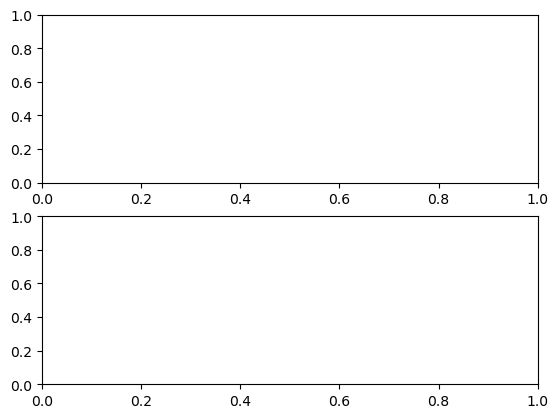

In [2]:
def plot_log():
    fig, ax = plt.subplots(2, 1)
    x = np.linspace(1, 2, 10)
    ax.plot(x, np.log(x))
    plt.show()

plot_log()  # Call the function, generate plot

این کد قصد دارد تابع `log` را در بازه $[1, 2]$ رسم کند.

اما اینجا یک خطا وجود دارد: `plt.subplots(2, 1)` باید فقط `plt.subplots()` باشد.

(فراخوانی `plt.subplots(2, 1)` یک آرایه NumPy حاوی دو شیء محور برمی‌گرداند که برای داشتن دو نمودار فرعی در یک شکل مناسب است)

ردیابی نشان می‌دهد که خطا در فراخوانی متد `ax.plot(x, np.log(x))` رخ می‌دهد.

خطا به این دلیل رخ می‌دهد که ما به اشتباه `ax` را یک آرایه NumPy کرده‌ایم و یک آرایه NumPy هیچ متد `plot` ندارد.

اما بیایید وانمود کنیم که در این لحظه این موضوع را نمی‌فهمیم.

ممکن است مشکوک باشیم که مشکلی با `ax` وجود دارد اما وقتی سعی می‌کنیم این شیء را بررسی کنیم، استثنای زیر را دریافت می‌کنیم:

In [3]:
ax

NameError: name 'ax' is not defined

مشکل این است که `ax` در داخل `plot_log()` تعریف شده است و نام
به محض پایان یافتن آن تابع از دست می‌رود.

بیایید آن را به روشی متفاوت امتحان کنیم.

بلوک سلول اول را دوباره اجرا می‌کنیم و همان خطا تولید می‌شود

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

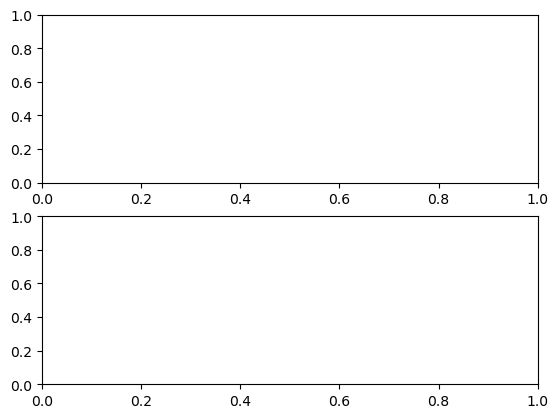

In [4]:
def plot_log():
    fig, ax = plt.subplots(2, 1)
    x = np.linspace(1, 2, 10)
    ax.plot(x, np.log(x))
    plt.show()

plot_log()  # Call the function, generate plot

اما این بار در بلوک سلول زیر تایپ می‌کنیم

```{code-block} ipython
:class: no-execute
%debug
```

شما باید به یک پرامپت جدید منتقل شوید که چیزی شبیه این به نظر می‌رسد

```{code-block} ipython
:class: no-execute
ipdb>
```

(ممکن است به جای آن pdb> ببینید)

اکنون می‌توانیم مقدار متغیرهای خود را در این نقطه از برنامه بررسی کنیم، از طریق کد به جلو حرکت کنیم و غیره.

به عنوان مثال، در اینجا ما به سادگی نام `ax` را تایپ می‌کنیم تا ببینیم با
این شیء چه اتفاقی می‌افتد:

```{code-block} ipython
:class: no-execute
ipdb> ax
array([<matplotlib.axes.AxesSubplot object at 0x290f5d0>,
       <matplotlib.axes.AxesSubplot object at 0x2930810>], dtype=object)
```

اکنون کاملاً واضح است که `ax` یک آرایه است که منبع
مشکل را روشن می‌کند.

برای اینکه بفهمید از داخل `ipdb` (یا `pdb`) چه کارهای دیگری می‌توانید انجام دهید، از
راهنمای آنلاین استفاده کنید

```{code-block} ipython
:class: no-execute
ipdb> h

Documented commands (type help <topic>):
========================================
EOF    bt         cont      enable  jump  pdef   r        tbreak   w
a      c          continue  exit    l     pdoc   restart  u        whatis
alias  cl         d         h       list  pinfo  return   unalias  where
args   clear      debug     help    n     pp     run      unt
b      commands   disable   ignore  next  q      s        until
break  condition  down      j       p     quit   step     up

Miscellaneous help topics:
==========================
exec  pdb

Undocumented commands:
======================
retval  rv

ipdb> h c
c(ont(inue))
Continue execution, only stop when a breakpoint is encountered.
```

### تنظیم یک نقطه توقف

رویکرد قبلی مفید است اما گاهی ناکافی است.

نسخه اصلاح‌شده زیر از تابع بالا را در نظر بگیرید

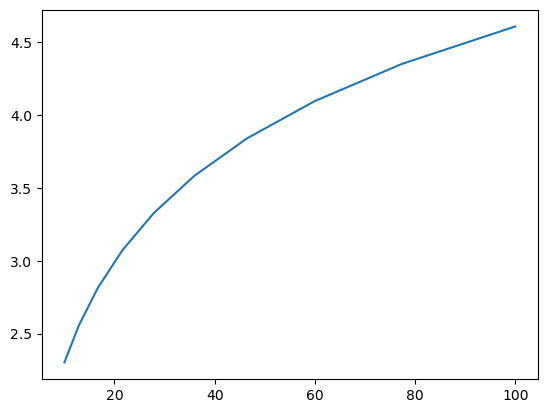

In [5]:
def plot_log():
    fig, ax = plt.subplots()
    x = np.logspace(1, 2, 10)
    ax.plot(x, np.log(x))
    plt.show()

plot_log()

در اینجا مشکل اصلی برطرف شده است، اما ما به طور تصادفی
`np.logspace(1, 2, 10)` را به جای `np.linspace(1, 2, 10)` نوشته‌ایم.

اکنون هیچ استثنایی وجود نخواهد داشت، اما نمودار درست به نظر نمی‌رسد.

برای بررسی، اگر بتوانیم متغیرهایی مانند `x` را در حین اجرای تابع بررسی کنیم مفید خواهد بود.

برای این منظور، با قرار دادن `breakpoint()` در داخل بلوک کد تابع یک "نقطه توقف" اضافه می‌کنیم

```{code-block} python3
:class: no-execute
def plot_log():
    breakpoint()
    fig, ax = plt.subplots()
    x = np.logspace(1, 2, 10)
    ax.plot(x, np.log(x))
    plt.show()

plot_log()
```

اکنون بیایید اسکریپت را اجرا کنیم و از طریق اشکال‌زدا بررسی کنیم

```{code-block} ipython
:class: no-execute
> <ipython-input-6-a188074383b7>(6)plot_log()
-> fig, ax = plt.subplots()
(Pdb) n
> <ipython-input-6-a188074383b7>(7)plot_log()
-> x = np.logspace(1, 2, 10)
(Pdb) n
> <ipython-input-6-a188074383b7>(8)plot_log()
-> ax.plot(x, np.log(x))
(Pdb) x
array([ 10.        ,  12.91549665,  16.68100537,  21.5443469 ,
        27.82559402,  35.93813664,  46.41588834,  59.94842503,
        77.42636827, 100.        ])
```

ما دو بار از `n` برای حرکت به جلو از طریق کد (یک خط در هر زمان) استفاده کردیم.

سپس مقدار `x` را چاپ کردیم تا ببینیم با آن متغیر چه اتفاقی می‌افتد.

برای خروج از اشکال‌زدا، از `q` استفاده کنید.

### دستورات جادویی مفید دیگر

در این سخنرانی، از دستور جادویی IPython به نام `%debug` استفاده کردیم.

بسیاری از دستورات جادویی مفید دیگر وجود دارند:

* `%precision 4` دقت چاپ برای اعداد اعشاری را به 4 رقم اعشار تنظیم می‌کند
* `%whos` فهرستی از متغیرها و مقادیر آنها را ارائه می‌دهد
* `%quickref` فهرستی از دستورات جادویی را ارائه می‌دهد

فهرست کامل دستورات جادویی [اینجا](https://ipython.readthedocs.io/en/stable/interactive/magics.html) است.


## مدیریت خطاها

```{index} single: Python; Handling Errors
```

گاهی اوقات ممکن است هنگام نوشتن کد، باگ‌ها و خطاها را پیش‌بینی کنیم.

به عنوان مثال، واریانس نمونه بی‌طرفانه نمونه $y_1, \ldots, y_n$
به صورت زیر تعریف می‌شود

$$
s^2 := \frac{1}{n-1} \sum_{i=1}^n (y_i - \bar y)^2
\qquad \bar y = \text{ میانگین نمونه}
$$

این می‌تواند با استفاده از `np.var` در NumPy محاسبه شود.

اما اگر تابعی برای انجام چنین محاسبه‌ای می‌نوشتید، ممکن است
یک خطای تقسیم بر صفر را هنگامی که اندازه نمونه یک است، پیش‌بینی کنید.

یک اقدام ممکن این است که کاری نکنید --- برنامه فقط سقوط می‌کند و یک پیام خطا نمایش می‌دهد.

اما گاهی اوقات ارزش دارد که کد خود را به گونه‌ای بنویسید که خطاهای زمان اجرا را که فکر می‌کنید ممکن است رخ دهند، پیش‌بینی کرده و با آنها برخورد کند.

چرا؟

* زیرا اطلاعات اشکال‌زدایی ارائه شده توسط مفسر اغلب کمتر مفید از آن چیزی است که می‌تواند توسط یک پیام خطای خوب نوشته شده ارائه شود.
* زیرا خطاهایی که باعث توقف اجرا می‌شوند، جریان‌های کاری را قطع می‌کنند.
* زیرا اعتماد به کد شما را از طرف کاربران (اگر برای دیگران می‌نویسید) کاهش می‌دهد.


در این بخش، انواع مختلف خطاها در Python و تکنیک‌هایی برای مدیریت خطاهای احتمالی در برنامه‌های خود را بحث خواهیم کرد.

### خطاها در Python

ما `AttributeError` و `NameError` را در {any}`مثال‌های قبلی خود <debug_magic>` دیده‌ایم.

در Python، دو نوع خطا وجود دارد -- خطاهای نحوی و استثناها.

```{index} single: Python; Exceptions
```

در اینجا مثالی از یک نوع خطای رایج آورده شده است

In [6]:
def f:

SyntaxError: expected '(' (2899452834.py, line 1)

از آنجایی که نحو غیرقانونی نمی‌تواند اجرا شود، یک خطای نحوی اجرای برنامه را خاتمه می‌دهد.

در اینجا نوع متفاوتی از خطا وجود دارد که به نحو مربوط نمی‌شود

In [7]:
1 / 0

ZeroDivisionError: division by zero

در اینجا یکی دیگر است

In [8]:
x1 = y1

NameError: name 'y1' is not defined

و دیگری

In [9]:
'foo' + 6

TypeError: can only concatenate str (not "int") to str

و دیگری

In [10]:
X = []
x = X[0]

IndexError: list index out of range

در هر مورد، مفسر ما را از نوع خطا آگاه می‌کند

* `NameError`، `TypeError`، `IndexError`، `ZeroDivisionError` و غیره.

در Python، این خطاها *استثناها* نامیده می‌شوند.

### ادعاها

```{index} single: Python; Assertions
```

گاهی اوقات خطاها را می‌توان با بررسی اینکه آیا برنامه شما همانطور که انتظار می‌رود اجرا می‌شود، از آنها جلوگیری کرد.

یک روش نسبتاً آسان برای مدیریت بررسی‌ها با کلمه کلیدی `assert` است.

به عنوان مثال، برای یک لحظه وانمود کنید که تابع `np.var` وجود
ندارد و ما باید خودمان آن را بنویسیم

In [11]:
def var(y):
    n = len(y)
    assert n > 1, 'Sample size must be greater than one.'
    return np.sum((y - y.mean())**2) / float(n-1)

اگر این را با یک آرایه با طول یک اجرا کنیم، برنامه خاتمه می‌یابد و
پیام خطای ما را چاپ می‌کند

In [12]:
var([1])

AssertionError: Sample size must be greater than one.

مزیت این است که می‌توانیم

* زودتر شکست بخوریم، به محض اینکه می‌دانیم مشکلی وجود دارد
* اطلاعات خاصی در مورد اینکه چرا یک برنامه در حال شکست است ارائه دهیم

### مدیریت خطاها در حین اجرا

```{index} single: Python; Runtime Errors
```

رویکرد استفاده شده در بالا کمی محدود است، زیرا همیشه منجر به
خاتمه می‌شود.

گاهی اوقات می‌توانیم خطاها را با ظرافت بیشتری، با رفتار با موارد خاص، مدیریت کنیم.

بیایید ببینیم چگونه این کار انجام می‌شود.

#### گرفتن استثناها

می‌توانیم استثناها را با استفاده از بلوک‌های `try` -- `except` بگیریم و با آنها برخورد کنیم.

در اینجا یک مثال ساده است

In [13]:
def f(x):
    try:
        return 1.0 / x
    except ZeroDivisionError:
        print('Error: division by zero.  Returned None')
    return None

وقتی `f` را فراخوانی می‌کنیم خروجی زیر را دریافت می‌کنیم

In [14]:
f(2)

0.5

In [15]:
f(0)

Error: division by zero.  Returned None


In [16]:
f(0.0)

Error: division by zero.  Returned None


خطا گرفته می‌شود و اجرای برنامه خاتمه نمی‌یابد.

توجه کنید که انواع خطاهای دیگر گرفته نمی‌شوند.

اگر نگران هستیم که کاربر ممکن است یک رشته را پاس دهد، می‌توانیم آن خطا را نیز بگیریم

In [17]:
def f(x):
    try:
        return 1.0 / x
    except ZeroDivisionError:
        print('Error: Division by zero.  Returned None')
    except TypeError:
        print(f'Error: x cannot be of type {type(x)}.  Returned None')
    return None

در اینجا اتفاقی که می‌افتد

In [18]:
f(2)

0.5

In [19]:
f(0)

Error: Division by zero.  Returned None


In [20]:
f('foo')

Error: x cannot be of type <class 'str'>.  Returned None


اگر احساس تنبلی می‌کنیم می‌توانیم این خطاها را با هم بگیریم

In [21]:
def f(x):
    try:
        return 1.0 / x
    except:
        print(f'Error.  An issue has occurred with x = {x} of type: {type(x)}')
    return None

در اینجا اتفاقی که می‌افتد

In [22]:
f(2)

0.5

In [23]:
f(0)

Error.  An issue has occurred with x = 0 of type: <class 'int'>


In [24]:
f('foo')

Error.  An issue has occurred with x = foo of type: <class 'str'>


به طور کلی بهتر است خاص باشید.


## تمرین‌ها

```{exercise-start}
:label: debug_ex1
```

فرض کنید ما یک فایل متنی `numbers.txt` داریم که شامل خطوط زیر است

```{code-block} none
:class: no-execute

prices
3
8

7
21
```

با استفاده از `try` -- `except`، برنامه‌ای بنویسید که محتویات فایل را بخواند و اعداد را جمع کند، خطوط بدون عدد را نادیده بگیرید.

می‌توانید از تابع `open()` که {any}`قبلاً<iterators>` یاد گرفتیم برای باز کردن `numbers.txt` استفاده کنید.
```{exercise-end}
```


```{solution-start} debug_ex1
:class: dropdown
```

بیایید ابتدا داده را ذخیره کنیم

In [25]:
%%file numbers.txt
prices
3
8

7
21

Writing numbers.txt


In [26]:
f = open('numbers.txt')

total = 0.0
for line in f:
    try:
        total += float(line)
    except ValueError:
        pass

f.close()

print(total)

39.0


```{solution-end}
```